In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print("Training dataset:", train.shape)
print("Testing dataset:", test.shape)
train.info()
train.describe()

Training dataset: (891, 12)
Testing dataset: (418, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


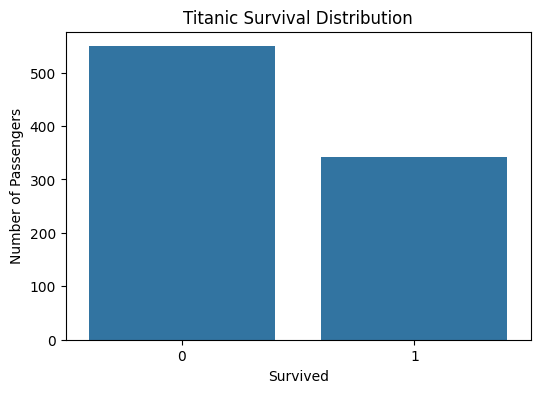

In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(data=train, x="Survived")
plt.title("Titanic Survival Distribution")
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")
plt.show()

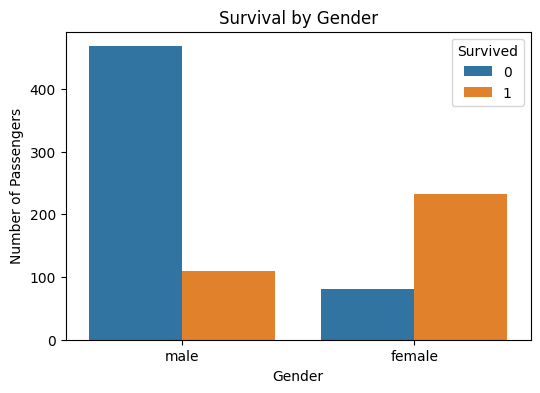

In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(data=train, x="Sex", hue="Survived")
plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.show()

In [6]:
train.groupby("Sex")["Survived"].mean()

,Survived
Sex,
female,0.742038
male,0.188908


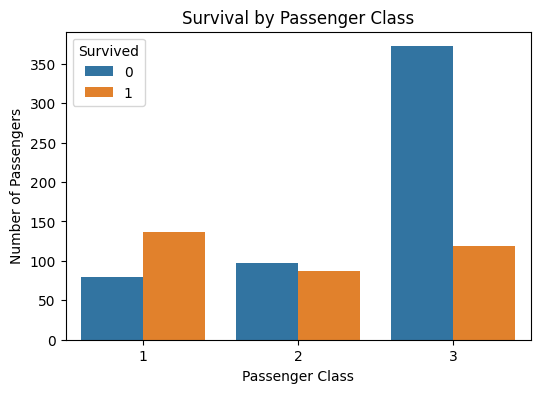

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(data=train, x="Pclass", hue="Survived")
plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.show()

In [8]:
train.groupby("Pclass")["Survived"].mean()

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


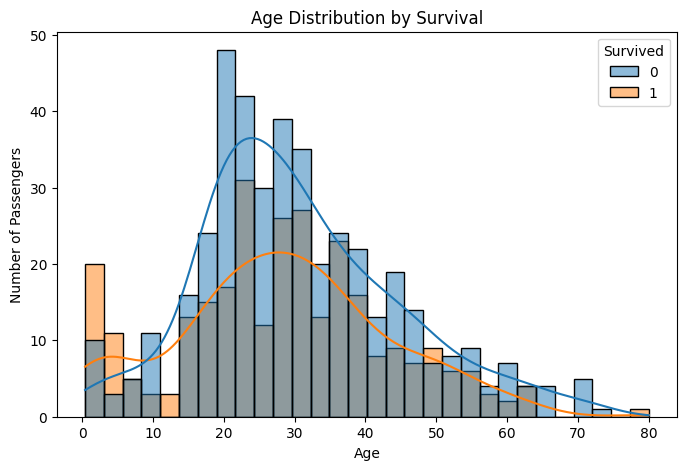

In [9]:
plt.figure(figsize=(8, 5))
sns.histplot(data=train,x="Age",hue="Survived",bins=30,kde=True)
plt.title("Age Distribution by Survival")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

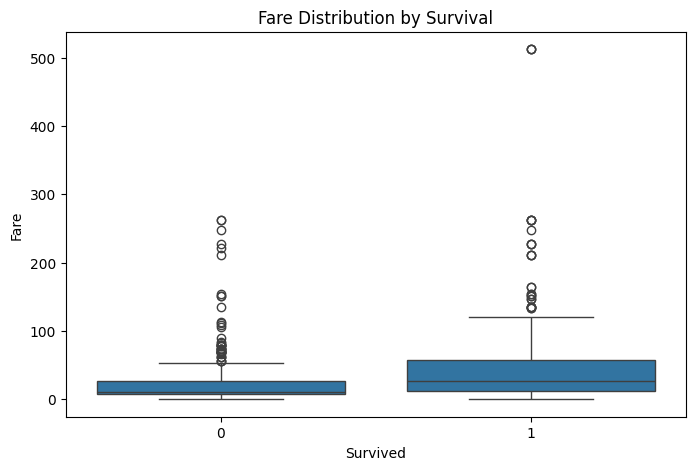

In [10]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=train,x="Survived",y="Fare")
plt.title("Fare Distribution by Survival")
plt.xlabel("Survived")
plt.ylabel("Fare")
plt.show()

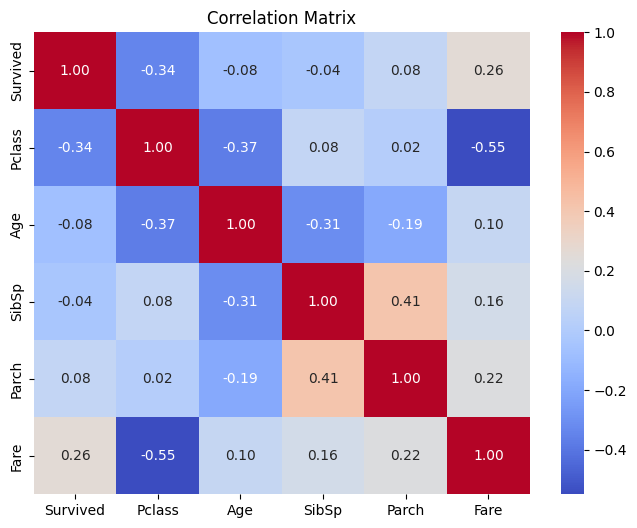

In [11]:
numeric_columns = [
    "Survived",
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]
plt.figure(figsize=(8, 6))
sns.heatmap(train[numeric_columns].corr(),annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [12]:
def feature_engineering(df):
    df = df.copy()

    # Family size
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

    # Whether passenger was travelling alone
    df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

    # Extract title from passenger name
    df["Title"] = df["Name"].str.extract(r",\s*([^.]*)\.", expand=False)

    # Group rare titles
    title_mapping = {
        "Mlle": "Miss",
        "Ms": "Miss",
        "Mme": "Mrs"
    }

    df["Title"] = df["Title"].replace(title_mapping)

    common_titles = ["Mr", "Miss", "Mrs", "Master"]

    df["Title"] = df["Title"].where(
        df["Title"].isin(common_titles),
        "Rare"
    )

    # Remove columns we won't use
    df.drop(
        columns=["PassengerId", "Name", "Ticket", "Cabin"],
        inplace=True
    )

    return df

In [13]:
train_processed = feature_engineering(train)
test_processed = feature_engineering(test)
train_processed.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,Title
0,0,3,male,22.0,1,0,7.2500,S,2,0,Mr
1,1,1,female,38.0,1,0,71.2833,C,2,0,Mrs
2,1,3,female,26.0,0,0,7.9250,S,1,1,Miss
3,1,1,female,35.0,1,0,53.1000,S,2,0,Mrs
4,0,3,male,35.0,0,0,8.0500,S,1,1,Mr


In [14]:
print("Original columns:")
print(train.columns.tolist())

print("\nProcessed columns:")
print(train_processed.columns.tolist())

Original columns:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Processed columns:
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'Title']


In [15]:
print(train_processed["FamilySize"].value_counts().sort_index())

FamilySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64


In [16]:
print(train_processed["IsAlone"].value_counts())

IsAlone
1    537
0    354
Name: count, dtype: int64


In [17]:
print(train_processed["Title"].value_counts())

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64


In [18]:
from sklearn.model_selection import train_test_split
X = train_processed.drop("Survived", axis=1)
y = train_processed["Survived"]
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (891, 10)
Target shape: (891,)


In [19]:
numeric_features = [
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize",
    "IsAlone",
    "Pclass"
]

categorical_features = [
    "Sex",
    "Embarked",
    "Title"
]

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'Pclass']

Categorical features:
['Sex', 'Embarked', 'Title']


In [20]:
X_train, X_val, y_train, y_val = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)
print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])

Training samples: 712
Validation samples: 179


In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [22]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix)
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)
logistic_model.fit(X_train, y_train)
y_pred_logistic = logistic_model.predict(X_val)
logistic_accuracy = accuracy_score(y_val, y_pred_logistic)

print("Logistic Regression Accuracy:",round(logistic_accuracy, 4))
print(classification_report(y_val, y_pred_logistic))
cm = confusion_matrix(y_val, y_pred_logistic)

print("Confusion Matrix:")
print(cm)

Logistic Regression Accuracy: 0.8547
              precision    recall  f1-score   support

           0       0.86      0.91      0.88       110
           1       0.84      0.77      0.80        69

    accuracy                           0.85       179
   macro avg       0.85      0.84      0.84       179
weighted avg       0.85      0.85      0.85       179

Confusion Matrix:
[[100  10]
 [ 16  53]]


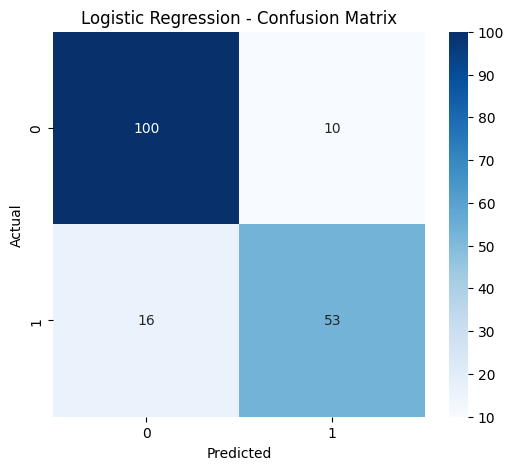

In [24]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    confusion_matrix(y_val, y_pred_logistic),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [25]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(
            max_depth=5,
            random_state=42
        ))
    ]
)

In [26]:
decision_tree_model.fit(X_train, y_train)
y_pred_tree = decision_tree_model.predict(X_val)
tree_accuracy = accuracy_score(y_val, y_pred_tree)
print("Decision Tree Accuracy:",round(tree_accuracy, 4))

Decision Tree Accuracy: 0.7989


In [27]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            max_depth=8,
            random_state=42
        ))
    ]
)
random_forest_model.fit(X_train, y_train)
y_pred_forest = random_forest_model.predict(X_val)
forest_accuracy = accuracy_score(y_val, y_pred_forest)
print("Random Forest Accuracy:",round(forest_accuracy, 4))

Random Forest Accuracy: 0.8156


In [28]:
knn_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", KNeighborsClassifier(
            n_neighbors=7
        ))
    ]
)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_val)
knn_accuracy = accuracy_score(y_val, y_pred_knn)
print("KNN Accuracy:",round(knn_accuracy, 4))

KNN Accuracy: 0.8045


In [29]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN"
    ],
    "Accuracy": [
        logistic_accuracy,
        tree_accuracy,
        forest_accuracy,
        knn_accuracy
    ]
})

model_results = model_results.sort_values(by="Accuracy",ascending=False).reset_index(drop=True)

model_results

,Model,Accuracy
0,Logistic Regression,0.854749
1,Random Forest,0.815642
2,KNN,0.804469
3,Decision Tree,0.798883


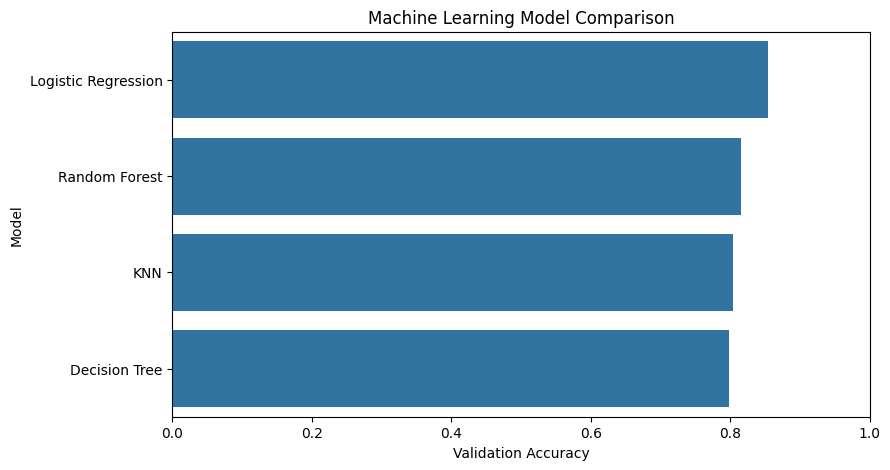

In [30]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=model_results,
    x="Accuracy",
    y="Model"
)

plt.xlim(0, 1)
plt.title("Machine Learning Model Comparison")
plt.xlabel("Validation Accuracy")
plt.ylabel("Model")

plt.show()

In [31]:
predictions = {
    "Logistic Regression": y_pred_logistic,
    "Decision Tree": y_pred_tree,
    "Random Forest": y_pred_forest,
    "KNN": y_pred_knn
}

for model_name, predictions_model in predictions.items():
    print("=" * 60)
    print(model_name)
    print("=" * 60)
    print(classification_report(y_val, predictions_model))

Logistic Regression
              precision    recall  f1-score   support

           0       0.86      0.91      0.88       110
           1       0.84      0.77      0.80        69

    accuracy                           0.85       179
   macro avg       0.85      0.84      0.84       179
weighted avg       0.85      0.85      0.85       179

Decision Tree
              precision    recall  f1-score   support

           0       0.79      0.92      0.85       110
           1       0.82      0.61      0.70        69

    accuracy                           0.80       179
   macro avg       0.81      0.76      0.77       179
weighted avg       0.80      0.80      0.79       179

Random Forest
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       110
           1       0.81      0.68      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.82   

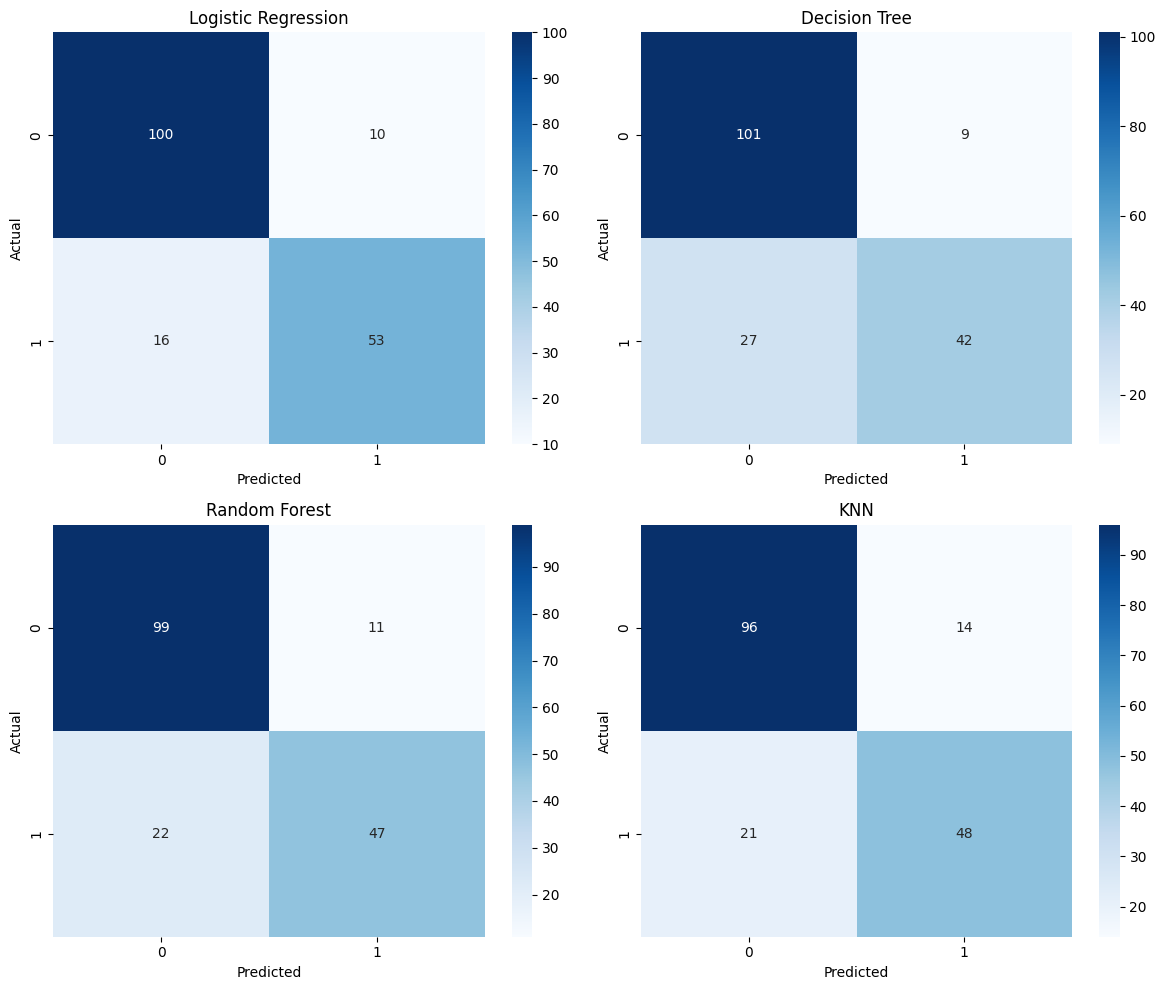

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (model_name, predictions_model) in zip(
    axes.ravel(),
    predictions.items()
):
    cm = confusion_matrix(y_val, predictions_model)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax
    )

    ax.set_title(model_name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [33]:
# Train the final model on the complete training dataset
logistic_model.fit(X, y)

# Prepare test features
X_test = test_processed

# Generate predictions
test_predictions = logistic_model.predict(X_test)

# Create Kaggle submission
submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": test_predictions
})

# Save submission file
submission.to_csv("submission.csv", index=False)

print("Submission file created!")
print(submission.head())

Submission file created!
   PassengerId  Survived
0          892         0
1          893         1
2          894         0
3          895         0
4          896         1


In [34]:
print(submission.shape)
print(submission["Survived"].value_counts())

(418, 2)
Survived
0    253
1    165
Name: count, dtype: int64
